In [9]:
import sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from contextlib import nullcontext
from pathlib import Path

# Import model classes from training codebase
TORCH_REPO = Path('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon')
sys.path.insert(0, str(TORCH_REPO / 'training'))
from agft_mpra_fulltwostep import (
    MPRAHead, load_pretrained_model, LentiMPRADataset,
    ENCODER_RESOLUTION_BP,
)
from alphagenome_pytorch.extensions.finetuning.utils import sequence_to_onehot

PROMOTER_SEQ = LentiMPRADataset.PROMOTER_SEQ
RAND_BARCODE = LentiMPRADataset.RAND_BARCODE

REPO = Path('/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra')
MODELS_DIR = REPO / 'models'
DATA_CSV = REPO / 'data' / 'joint_library_combined.csv'
WEIGHTS = str(TORCH_REPO / 'weights' / 'model_fold_0.safetensors')

CELL_TYPES = ['HepG2', 'K562', 'WTC11']
DROPOUTS = ['do03', 'do06', 'do075']

MODELS = {(ct, do): f'{ct}_v6_{do}' for ct in CELL_TYPES for do in DROPOUTS}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'{len(MODELS)} models: {list(MODELS.values())}')

Device: cuda
9 models: ['HepG2_v6_do03', 'HepG2_v6_do06', 'HepG2_v6_do075', 'K562_v6_do03', 'K562_v6_do06', 'K562_v6_do075', 'WTC11_v6_do03', 'WTC11_v6_do06', 'WTC11_v6_do075']


In [10]:
def load_model(model_dir, device):
    with open(model_dir / 'args.json') as f:
        hp = json.load(f)['hp']
    model = load_pretrained_model(WEIGHTS, device)
    seq_len = hp.get('sequence_length', 384)
    n_pos = seq_len // ENCODER_RESOLUTION_BP
    head = MPRAHead(n_pos, hp.get('nl_size', 1024), hp.get('dropout', 0.1),
                    hp.get('activation', 'relu'), hp.get('pooling_type', 'flatten'),
                    hp.get('center_bp', 256)).to(device)
    s2 = model_dir / 'best_stage2.pt'
    s1 = model_dir / 'best_head.pt'
    ckpt_path = s2 if s2.exists() else s1
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    if 'model_state_dict' in ckpt:
        # stage2 checkpoint only saved encoder keys (skipped tower/decoder)
        model.load_state_dict(ckpt['model_state_dict'], strict=False)
    head.load_state_dict(ckpt['head_state_dict'])
    model.eval(); head.eval()
    return model, head, hp

@torch.no_grad()
def predict(model, head, sequences, seq_len=384, batch_size=64):
    amp_ctx = torch.autocast('cuda', dtype=torch.bfloat16) if device.type == 'cuda' else nullcontext()
    all_preds = []
    for i in range(0, len(sequences), batch_size):
        batch = []
        for s in sequences[i:i+batch_size]:
            oh = sequence_to_onehot(s + PROMOTER_SEQ + RAND_BARCODE).astype(np.float32)
            L = oh.shape[0]
            if L < seq_len:
                oh = np.concatenate([oh, np.zeros((seq_len - L, 4), dtype=np.float32)])
            else:
                oh = oh[:seq_len]
            batch.append(oh)
        t = torch.from_numpy(np.stack(batch)).to(device)
        org = torch.zeros(t.shape[0], dtype=torch.long, device=device)
        with amp_ctx:
            enc = model(t, org, encoder_only=True)['encoder_output'].transpose(1, 2)
            preds = head(enc)
        all_preds.append(preds.float().cpu().numpy())
    return np.concatenate(all_preds)

In [ ]:
df = pd.read_csv(DATA_CSV)
sequences = df['sequence'].dropna().tolist()
valid_mask = df['sequence'].notna()
print(f'{len(sequences)} valid sequences')

results = {}
for (ct, do), mname in MODELS.items():
    print(f'\n--- {ct} {do} ({mname}) ---')
    model, head, hp = load_model(MODELS_DIR / mname, device)
    preds = predict(model, head, sequences, hp.get('sequence_length', 384), batch_size=256)
    actual = df.loc[valid_mask, f'{ct}_log2FC'].values
    mask = ~np.isnan(actual)
    r, _ = pearsonr(preds[mask], actual[mask])
    rho, _ = spearmanr(preds[mask], actual[mask])
    mse = float(np.mean((preds[mask] - actual[mask]) ** 2))
    results[(ct, do)] = {'preds': preds[mask], 'actual': actual[mask], 'r': r, 'rho': rho, 'mse': mse}
    print(f'  Pearson r = {r:.4f}  Spearman rho = {rho:.4f}  MSE = {mse:.4f}  (n={mask.sum()})')
    del model, head
    torch.cuda.empty_cache()

56978 valid sequences

--- HepG2 do03 (HepG2_v6_do03) ---
Loading pretrained weights from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors ...
  Pearson r = 0.8750  Spearman rho = 0.8586  MSE = 0.1379  (n=56978)

--- HepG2 do06 (HepG2_v6_do06) ---
Loading pretrained weights from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors ...
  Pearson r = 0.8665  Spearman rho = 0.8541  MSE = 0.1751  (n=56978)

--- HepG2 do075 (HepG2_v6_do075) ---
Loading pretrained weights from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors ...
  Pearson r = 0.8703  Spearman rho = 0.8540  MSE = 0.5367  (n=56978)

--- K562 do03 (K562_v6_do03) ---
Loading pretrained weights from /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors ...
  Pearson r = 0.8683  Spearman rho = 0.8422  MSE = 0.19

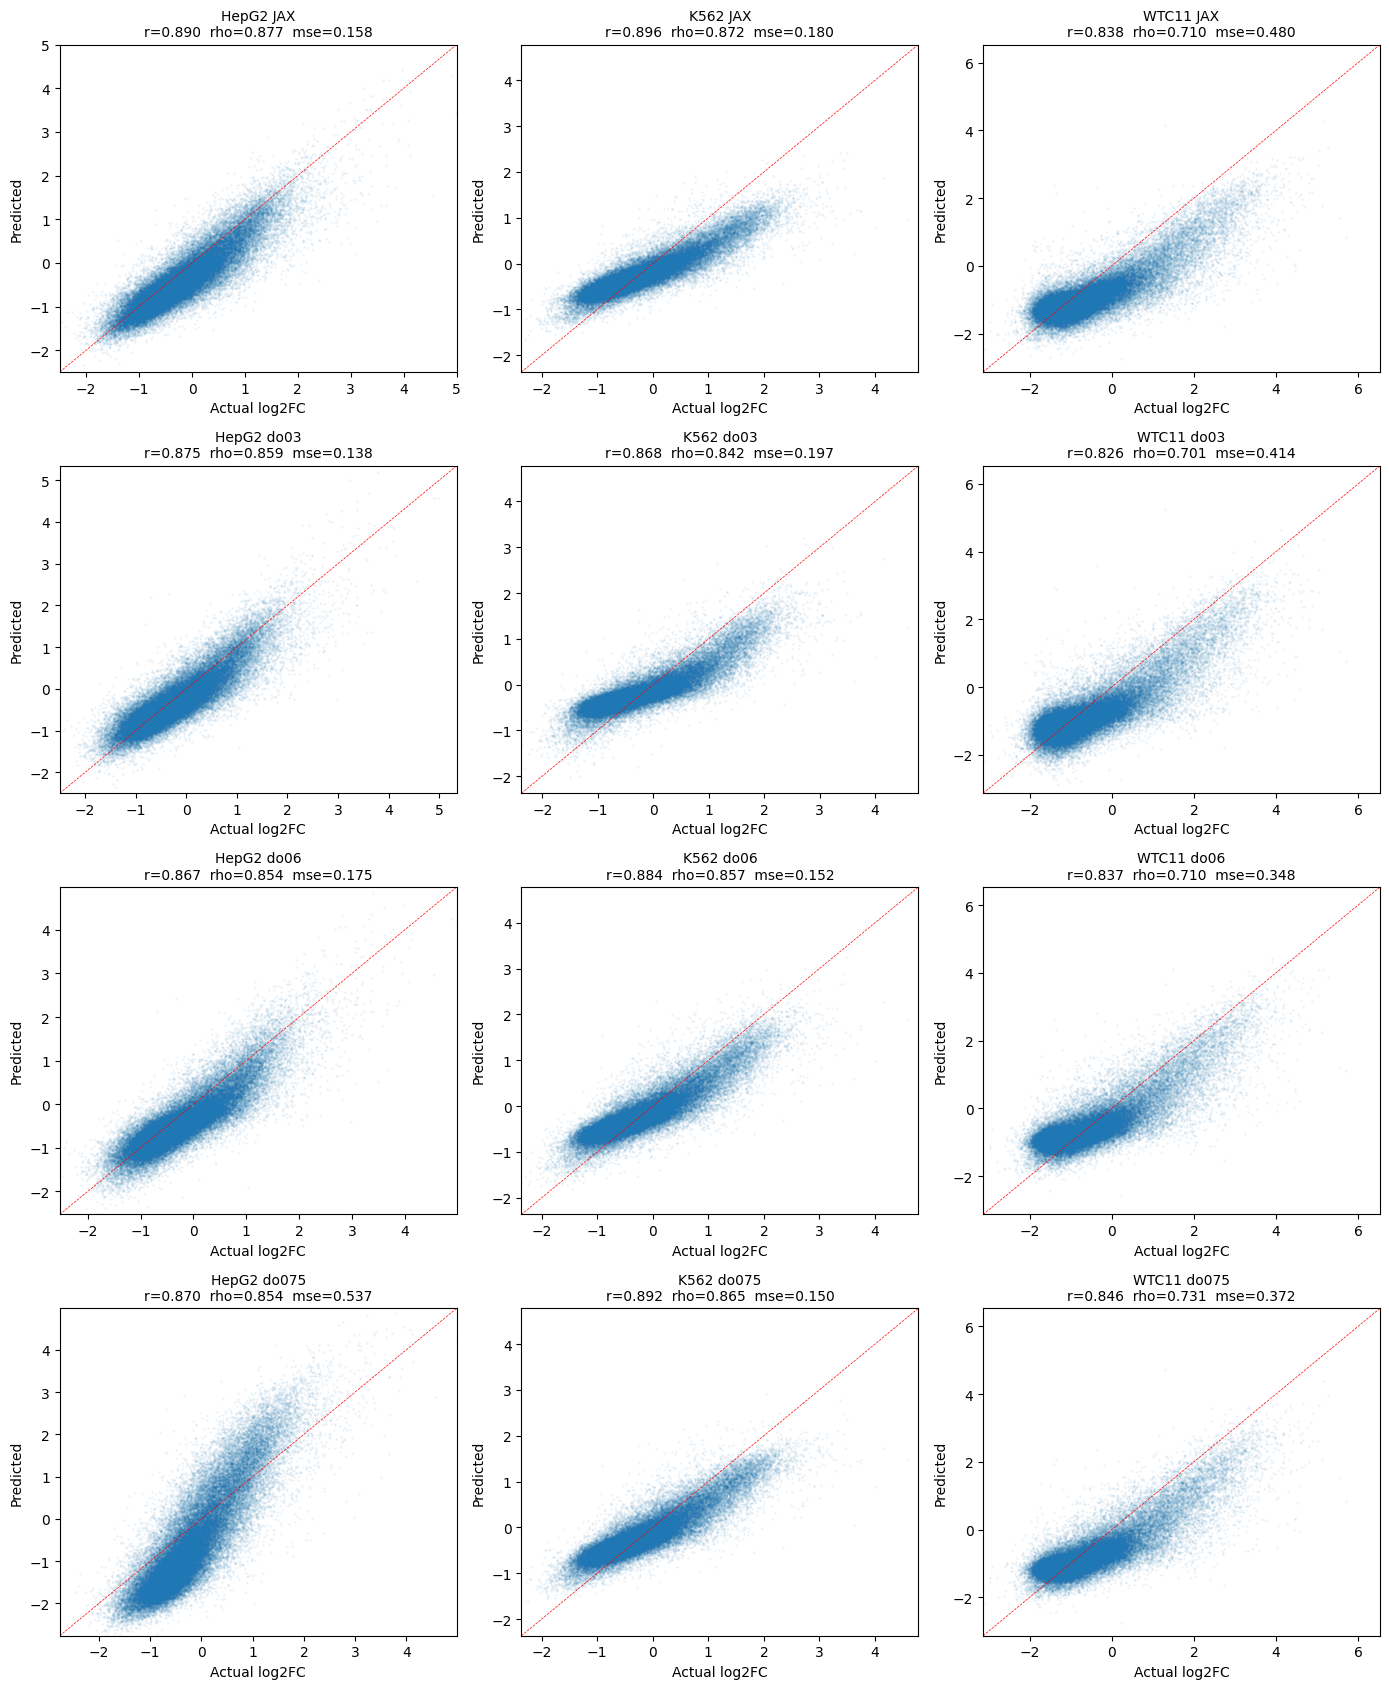

In [12]:
# Load JAX predictions
jax_df = pd.read_csv('/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/Cross-line_analysis/pred_first/joint_results/joint_library_predictions.csv')
jax_col_map = {'HepG2': 'hepg2_pred', 'K562': 'k562_pred', 'WTC11': 'wtc11_pred'}

jax_results = {}
for ct in CELL_TYPES:
    actual = jax_df[f'{ct}_log2FC'].values
    preds = jax_df[jax_col_map[ct]].values
    m = ~np.isnan(actual) & ~np.isnan(preds)
    r, _ = pearsonr(preds[m], actual[m])
    rho, _ = spearmanr(preds[m], actual[m])
    mse = float(np.mean((preds[m] - actual[m]) ** 2))
    jax_results[ct] = {'preds': preds[m], 'actual': actual[m], 'r': r, 'rho': rho, 'mse': mse}

# 4 rows (JAX + 3 dropouts) x 3 cols (cell types)
row_labels = ['JAX'] + DROPOUTS
fig, axes = plt.subplots(4, 3, figsize=(14, 17))
for col, ct in enumerate(CELL_TYPES):
    for row, label in enumerate(row_labels):
        ax = axes[row, col]
        if label == 'JAX':
            r = jax_results[ct]
        else:
            r = results[(ct, label)]
        ax.scatter(r['actual'], r['preds'], alpha=0.05, s=1, rasterized=True)
        lims = [min(r['actual'].min(), r['preds'].min()),
                max(r['actual'].max(), r['preds'].max())]
        ax.plot(lims, lims, 'r--', lw=0.5)
        ax.set_xlabel('Actual log2FC'); ax.set_ylabel('Predicted')
        ax.set_title(f'{ct} {label}\nr={r["r"]:.3f}  rho={r["rho"]:.3f}  mse={r["mse"]:.3f}', fontsize=10)
        ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.savefig(REPO / 'genomic_targets' / 'scripts' / 'model_validation.png', dpi=150)
plt.show()